# Thermal beam generation

Here we use ``atomsmltr`` for a rather simple example: illustrate the generation of a thermal beam of atoms using a collimation tube.

## Context


We start from an oven containing a gas of atoms of mass $m$ with a temperature $T$. According to Boltzmann's law, the probability distribution for each component $(v_x, v_y, v_z)$ of the speed is given by :

$$
f_\mathrm{Btz,i}(v_i) = \left(\frac{m}{2\pi k_B T}\right)^{1/2} \exp\left( -\frac{m v_i^2}{2k_B T}\right),
$$

that is a normal distribution with $\sigma = \sqrt{k_B T / m}$. The oven has a single cylinder-shaped opening, with a radius $r$ and a length $L$, that will collimate the beam.

In the following, we will also use Boltzmann's speed norm distribution $f_\mathrm{Btz, norm}(v) \equiv P_\mathrm{Btz}(|\vec{v}| = v)$, given by :

$$
f_\mathrm{Btz, norm}(v) = 4\pi\left(\frac{m}{2\pi k_B T}\right)^{3/2} v^2 \exp\left(-\frac{m v^2}{2 k_B T}\right)
$$

Finally, when collimating a beam with a tube of diameter $d$ and of length $L$, we expect the following axial velocity distribution (TODO : compute good normalization) :

$$
f_\mathrm{coll, ax}(v) \sim \left( \frac{m}{2\pi k_B T} \right)^{1/2} \exp\left(-\frac{m v^2}{2 k_B T} \right) \left \{ 1 - \exp\left(- \frac{m v^2}{2 k_B T} \frac{d^2}{L^2}\right) \right\}
$$

## Simulation

We will simulate this situation using zones to select atoms that can exit the oven through the tube. This way of solving the problem is arguably overkill, but why not ?

### Imports

In [258]:
# -- atomsmtlr imports
from atomsmltr.simulation import Configuration, RK4
from atomsmltr.atoms import Ytterbium
from atomsmltr.environment import Box, Cylinder, Limits, LowerLimit

# -- other imports
import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as csts
from IPython.display import display, clear_output
from scipy.stats import norm

### Generate a thermal distribution

Let's start by defining some functions to generate thermal distributions

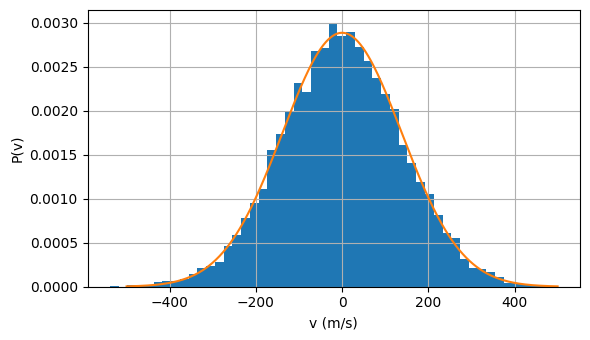

In [244]:
# %% 1D DISTRIBUTION


# - functions
def gen_1D_speed_distrib(N, T, m):
    """Generates a 1D thermal speed distribution,
    with N samples, a temperature T (K) and a mass m (kg)
    """
    rng = np.random.default_rng()
    sigma = np.sqrt(csts.k * T / m)
    v = rng.normal(0, sigma, N)
    return v


def f_Btz(v, T, m):
    """Boltzmann distribution for speed v (m/s)
    temperature T (K) and mass m (kg)
    """
    prefac = np.sqrt(m / 2 / np.pi / csts.k / T)
    exp = np.exp(-m * v**2 / 2 / csts.k / T)
    return prefac * exp

# - test
# settings
T = 400
m = Ytterbium().mass
N = 10_000
# generate
v = gen_1D_speed_distrib(N, T, m)
v_list = np.linspace(-500, 500, 1000)
# plot
plt.figure(figsize=(6, 3.5), tight_layout=True)
plt.hist(v, bins=50, density=True)
plt.plot(v_list, f_Btz(v_list, T, m))
plt.grid()
plt.xlabel("v (m/s)")
plt.ylabel("P(v)")
plt.show()

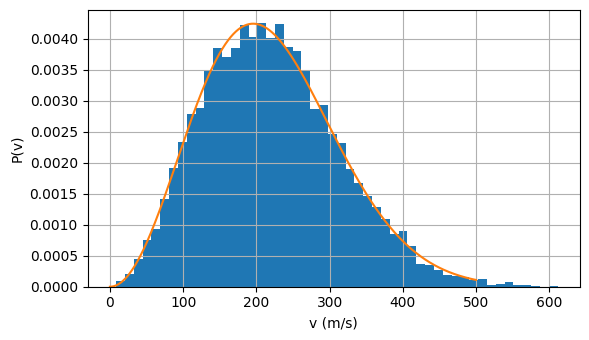

In [ ]:
# %% 3D DISTRIBUTION


# - functions
def gen_3D_speed_distrib(N, T, m):
    """Generates a 3D thermal speed distribution,
    with N samples, a temperature T (K) and a mass m (kg).

    Returns an array of shape (N, 3), according to our
    spatial coordinate conventions.
    """
    vx = gen_1D_speed_distrib(N, T, m)
    vy = gen_1D_speed_distrib(N, T, m)
    vz = gen_1D_speed_distrib(N, T, m)
    v = np.array([vx, vy, vz]).T
    return v


def f_Btz_norm(v, T, m):
    """Boltzmann norm distribution in 3D, for speed norm v (m/s)
    temperature T (K) and mass m (kg)
    """
    prefac = 4 * np.pi * (m / 2 / np.pi / csts.k / T) ** (3 / 2)
    exp = np.exp(-m * v**2 / 2 / csts.k / T)
    return prefac * v**2 * exp


# - test
# settings
T = 400
m = Ytterbium().mass
N = 10_000
# generate
v = gen_3D_speed_distrib(N, T, m)
# compute norm
v_norm = np.linalg.norm(v, axis=-1)
v_list = np.linspace(0, 500, 1000)
# plot
plt.figure(figsize=(6, 3.5), tight_layout=True)
plt.hist(v_norm, bins=50, density=True)
plt.plot(v_list, f_Btz_norm(v_list, T, m))
plt.grid()
plt.xlabel("v (m/s)")
plt.ylabel("P(v)")
plt.show()

### Define configuration with zones

We will define an experiment zone consisting of :

* an oven : a box of dimensions Lx × Ly × Lz
* a collimation tube : cylinder of radius r and lenght l, along z
* a tube end zone : at the end of the tube, to check if atoms are transmitted.

In [ ]:
def gen_zones(Lx, Ly, Lz, r, l):
    """Generates the zones we need for the configuration
    Oven size : Lx * Ly * Lz
    Tube : radius r length l
    """
    # - oven = Box
    oven_dim = (-Lx / 2, Lx / 2, -Ly / 2, Ly / 2, -Lz / 2, Lz / 2)
    oven = Box(*oven_dim, target="position", action="stop", tag="oven")

    # - tube = infinite cylinder & limits
    # cylinder (infinite)
    tube_cyl = Cylinder(
        origin=(0, 0, 0),
        direction=(0, 0, 1),
        radius=r,
        target="position",
        tag="tube cylinder",
    )
    # limits
    tube_lims = Limits(Lz / 2, Lz / 2 + l, axis=2, target="position", tag="tube limits")
    # combine
    tube = tube_cyl & tube_lims
    tube.tag = "tube"
    tube.action = "stop"
    tube.target = "position"

    # - end zone
    end_zone = LowerLimit(
        Lz / 2 + l,
        axis=2,
        target="position",
        action="ignore",
        in_tag="collimated",
        tag="tube end",
    )

    return oven, tube, end_zone


def gen_grid(Lx, Ly, Lz, l):
    # prepare grid
    # xy
    grid_xy = np.mgrid[-Lx:Lx:500j, -Ly:Ly:500j, 0:0:1j]
    grid_xy = np.squeeze(grid_xy)
    X, Y, _ = grid_xy
    X, Y = X.T, Y.T
    pos_xy = grid_xy.T

    # xz
    grid_xz = np.mgrid[-Lx:Lx:500j, 0:0:1j, -Lz : Lz + l : 500j]
    grid_xz = np.squeeze(grid_xz)
    _, _, Z = grid_xz
    pos_xz = grid_xz.T
    Z = Z.T

    return X, Y, Z, pos_xy, pos_xz


# - test
# settings
Lx = Ly = Lz = 10e-2
r = 4e-3
l = 8e-2

# generate
oven, tube, end_zone = gen_zones(Lx, Lz, Ly, r, l)

# print infos
tube.print_info()
oven.print_info()
end_zone.print_info()

───────────────────────
| AND Zone Collection |
───────────────────────
. Parameters :
  ├── type : AND Zone Collection
  ├── tag : tube
  ├── in_tag
  ├── out_tag
  ├── target : position
  ├── action : stop
  ├── zones : ['tube cylinder', 'tube limits']
  └── inverted : False


──────────
| 3D Box |
──────────
. Parameters :
  ├── type : 3D Box
  ├── tag : oven
  ├── in_tag
  ├── out_tag : oven
  ├── target : position
  ├── action : stop
  ├── xmin, xmax : (-0.05, 0.05)
  ├── ymin, ymax : (-0.05, 0.05)
  ├── zmin, zmax : (-0.05, 0.05)
  └── inverted : False


───────────────
| Upper Limit |
───────────────
. Parameters :
  ├── type : 1D lower limit
  ├── tag : tube end
  ├── in_tag : collimated
  ├── out_tag : tube end
  ├── target : position
  ├── action : ignore
  ├── value : 0.13
  ├── axis : 2
  └── inverted : False




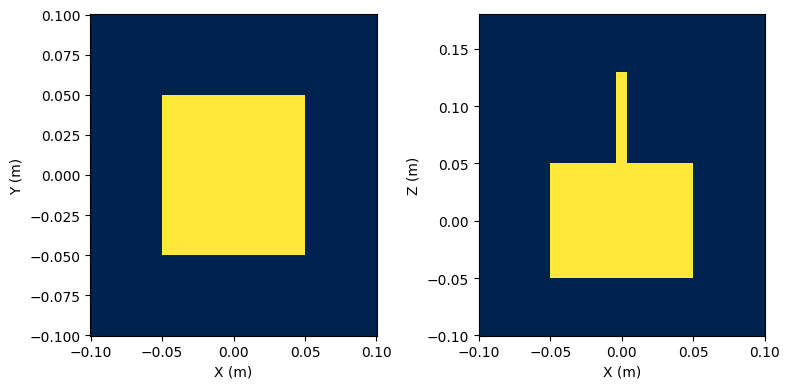

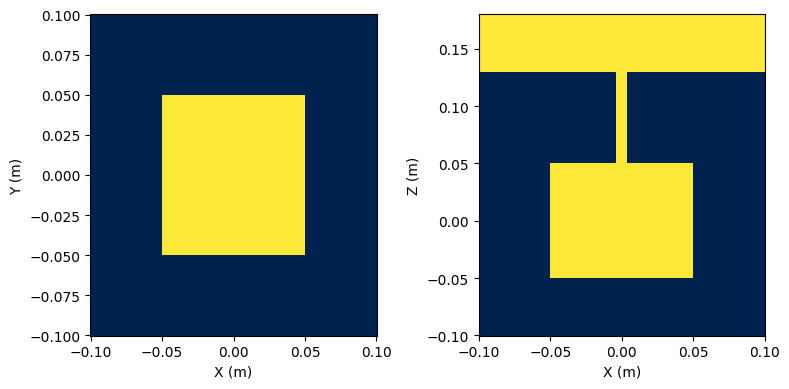

In [ ]:
# -- plot the zones
# settings
Lx = Ly = Lz = 10e-2
r = 4e-3
l = 8e-2

# generate zones
oven, tube, end_zone = gen_zones(Lx, Lz, Ly, r, l)

# prepare grid
# xy
X, Y, Z, pos_xy, pos_xz = gen_grid(Lx, Ly, Lz, l)

# oven + tube
exp_zone = oven | tube

fig, axes = plt.subplots(1, 2, figsize=(8, 4), tight_layout=True)
axes[0].pcolormesh(X, Y, exp_zone.get_value(pos_xy), cmap="cividis")
axes[0].set_xlabel("X (m)")
axes[0].set_ylabel("Y (m)")
axes[1].pcolormesh(X, Z, exp_zone.get_value(pos_xz), cmap="cividis")
axes[1].set_xlabel("X (m)")
axes[1].set_ylabel("Z (m)")

# oven + tube + end zone
exp_zone = oven | tube | end_zone

fig, axes = plt.subplots(1, 2, figsize=(8, 4), tight_layout=True)
axes[0].pcolormesh(X, Y, exp_zone.get_value(pos_xy), cmap="cividis")
axes[0].set_xlabel("X (m)")
axes[0].set_ylabel("Y (m)")
axes[1].pcolormesh(X, Z, exp_zone.get_value(pos_xz), cmap="cividis")
axes[1].set_xlabel("X (m)")
axes[1].set_ylabel("Z (m)")

plt.show()

### Simulation #1 : large tube
To check our simulation, we start with atoms generated at the center of the oven, and a large tube

In [32]:
# -- Settings
# atoms
m = Ytterbium().mass
T = 400
N = 1000

# geometry
Lx = Ly = Lz = 10e-2
r = 2e-2
l = 8e-2

# duration ?
typical_speed = np.sqrt(csts.k * T / m)
tmax = (l + Lz) / typical_speed * 2
t = np.linspace(0, tmax, 100)

# -- Prepare config
# initial conditions
v = gen_3D_speed_distrib(N, T, m)
vx, vy, vz = v.T
x = np.zeros_like(vx)
y = np.zeros_like(vx)
z = np.zeros_like(vx)

u0 = np.array([x, y, z, vx, vy, vz]).T

# zones
oven, tube, end_zone = gen_zones(Lx, Lz, Ly, r, l)
exp_zone = oven | tube
exp_zone.target = "position"
exp_zone.tag = "exp zone"
exp_zone.action = "stop"
exp_zone.out_tag = "stopped"

# config
config = Configuration(atom=Ytterbium())
config += exp_zone, end_zone

# -- run simulation
sim = RK4(config)
res = sim.integrate(u0, t)

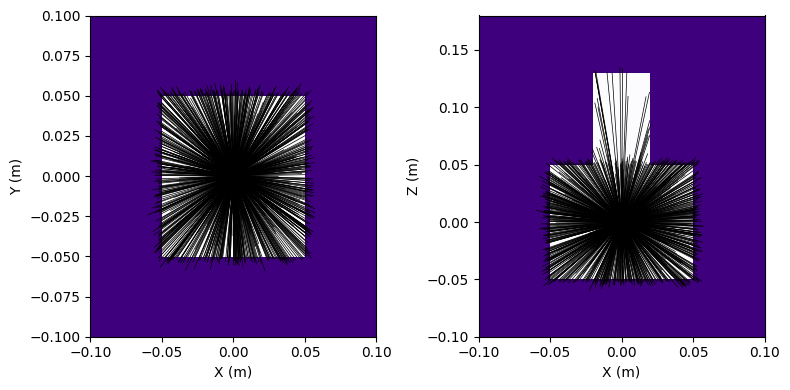

In [ ]:
# -- plot resuts : Full trajectory
fig, axes = plt.subplots(1, 2, figsize=(8, 4), tight_layout=True)

# exp zone
X, Y, Z, pos_xy, pos_xz = gen_grid(Lx, Ly, Lz, l)
exp_zone = oven | tube
axes[0].pcolormesh(X, Y, exp_zone.get_value(pos_xy), cmap="Purples_r")
axes[1].pcolormesh(X, Z, exp_zone.get_value(pos_xz), cmap="Purples_r")

# trajectories
y = res.y.T  # shape (len(t), 6, ...)
y = y.reshape((len(res.t), 6, -1))
axes[0].plot(y[:, 0], y[:, 1], "k", linewidth=0.5)
axes[1].plot(y[:, 0], y[:, 2], "k", linewidth=0.5)


# setup
axes[0].set_xlabel("X (m)")
axes[0].set_ylabel("Y (m)")
axes[0].set_xlim(X.min(), X.max())
axes[0].set_ylim(Y.min(), Y.max())
axes[1].set_xlabel("X (m)")
axes[1].set_ylabel("Z (m)")
axes[1].set_xlim(X.min(), X.max())
axes[1].set_ylim(Z.min(), Z.max())
plt.show()

Now let's use the tags to see what happened to the atoms :

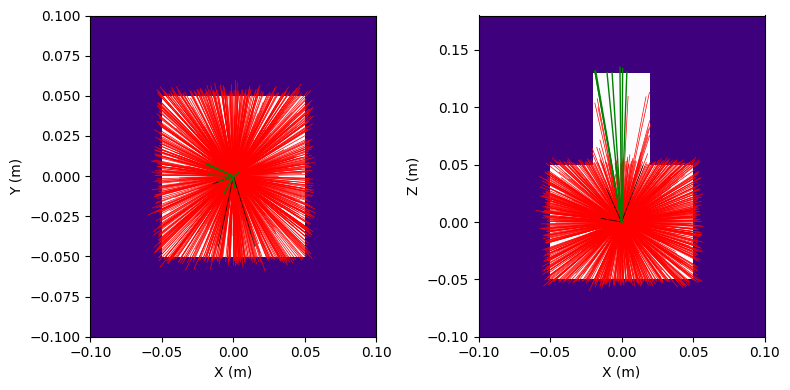

In [ ]:
# -- plot resuts : only use last step
fig, axes = plt.subplots(1, 2, figsize=(8, 4), tight_layout=True)

# exp zone
X, Y, Z, pos_xy, pos_xz = gen_grid(Lx, Ly, Lz, l)
exp_zone = oven | tube
axes[0].pcolormesh(X, Y, exp_zone.get_value(pos_xy), cmap="Purples_r")
axes[1].pcolormesh(X, Z, exp_zone.get_value(pos_xz), cmap="Purples_r")

# trajectories
tags = res.tags.T.reshape(-1)
y_last = res.y_last.T.reshape(6, -1)
for tg, u in zip(tags, y_last.T):
    x, y, z, _, _, _ = u
    if "collimated" in tg:
        axes[0].plot((0, x), (0, y), "g", linewidth=1, zorder=3)
        axes[1].plot((0, x), (0, z), "g", linewidth=1, zorder=3)
    elif "stopped" in tg:
        axes[0].plot((0, x), (0, y), "r", linewidth=0.5, zorder=1)
        axes[1].plot((0, x), (0, z), "r", linewidth=0.5, zorder=1)
    else:
        axes[0].plot((0, x), (0, y), "k", linewidth=0.5, zorder=2)
        axes[1].plot((0, x), (0, z), "k", linewidth=0.5, zorder=2)

# setup
axes[0].set_xlabel("X (m)")
axes[0].set_ylabel("Y (m)")
axes[0].set_xlim(X.min(), X.max())
axes[0].set_ylim(Y.min(), Y.max())
axes[1].set_xlabel("X (m)")
axes[1].set_ylabel("Z (m)")
axes[1].set_xlim(X.min(), X.max())
axes[1].set_ylim(Z.min(), Z.max())
plt.show()

### Simulation #2 : extract distribution of collimated atoms

Now we will repeat the experiment and keep only collimated trajectories

In [50]:
# -- Settings for the config
# atoms
m = Ytterbium().mass
T = 400

# geometry
Lx = Ly = Lz = 10e-2
r = 1e-2
l = 8e-2

# zones
oven, tube, end_zone = gen_zones(Lx, Lz, Ly, r, l)
exp_zone = oven | tube
exp_zone.target = "position"
exp_zone.tag = "exp zone"
exp_zone.action = "stop"
exp_zone.out_tag = "stopped"

# config
config = Configuration(atom=Ytterbium())
config += exp_zone, end_zone

We will need a function to perform the simulation on a given speed distribution

In [ ]:
def simulate(tmax, Npoints, Natoms, T, config, start_at_center=True, prefilter=True):
    t = np.linspace(0, tmax, Npoints)

    # -- Prepare config
    # speed
    v = gen_3D_speed_distrib(Natoms, T, m)
    vx, vy, vz = v.T
    # prefilter ?
    if prefilter:
        i = np.logical_and.reduce([vz > 0, np.abs(vz) > np.abs(np.sqrt(vx**2 + vy**2))])
        vx = vx[i]
        vy = vy[i]
        vz = vz[i]
    # position
    if start_at_center:
        x = y = z = np.zeros_like(vx)
    else:
        # get oven zone
        exp_zone = config.get_zone_copy("exp zone")
        for z in exp_zone.zones:
            if z.tag == "oven":
                oven = z
        x = np.random.uniform(oven.xmin, oven.xmax, vx.shape)
        y = np.random.uniform(oven.ymin, oven.ymax, vx.shape)
        z = np.random.uniform(oven.zmin, oven.zmax, vx.shape)
    u0 = np.array([x, y, z, vx, vy, vz]).T

    # -- run simulation
    sim = RK4(config)
    res = sim.integrate(u0, t)

    # -- keep only last
    tags = res.tags.T.reshape(-1).T
    y_last = res.y_last.T.reshape(6, -1).T
    del res
    return y_last, tags

And a function to iterate till we reach a good number of collimated atoms

In [229]:
def collimate_atoms(N_target, max_iter, *args, **kwargs):
    # -- Simulate
    v_coll = None
    N_gen = 0
    N_coll = 0
    N_flying = 0
    i = 0

    while N_coll < N_target and i < max_iter:
        # simulate
        y, tags = simulate(*args, **kwargs)

        # collected collimated
        coll = np.array(["collimated" in tg for tg in tags])
        not_stopped = np.array(["stopped" not in tg for tg in tags])
        y_coll = y[np.where(coll)]
        if np.sum(coll):
            if v_coll is None:
                v_coll = y_coll[:, 3:]
            else:
                v_coll = np.vstack([v_coll, y_coll[:, 3:]])

        # increment
        N_coll += np.sum(coll)
        N_flying += np.sum(not_stopped)
        N_gen += len(tags)
        i += 1
        x = N_coll / N_target * 100
        clear_output(wait=True)
        display(f"Iteration {i} / {max_iter} | Atoms {N_coll} / {N_target} ({x:.2f}%)")

    del y, tags

    # -- Print
    print("DONE !!")
    print(f"  > collimated atoms   : {N_coll}  ({N_coll / N_gen * 100 :.2f}%) ")
    print(f"  > atoms still flying : {N_flying}  ({N_flying / N_gen * 100 :.2f}%) ")

    res = {"N_coll": N_coll, "N_flying": N_flying, "N_gen": N_gen, "v": v_coll}
    return res

and the theoretical distribution

In [ ]:
def f_coll_ax(v, T, m, d, L):
    """axial speed distribution after collimation
    for speed v (m/s), temperature T (K) and mass m (kg)
    with a tube of diameter d (m) and lenght L (m)

    NOTE : normalization is not good
    TODO : compute good normalization
    """
    prefac = np.sqrt(m / 2 / np.pi / csts.k / T)
    exp = np.exp(-m * v**2 / 2 / csts.k / T)
    exp2 = np.exp(-m * v**2 / 2 / csts.k / T * d**2 / L**2)
    return prefac * exp * (1 - exp2)

and a plotting function

In [269]:
def plot_distrib(res, tube_diameter, tube_length, T, m, show=True):
    # -- preparation
    # get data
    vx, vy, vz = res["v"].T

    # compute theoretical distrib
    v = np.linspace(0, 1000, 1000)
    P = f_coll_ax(v, T, m, tube_diameter, tube_length)
    P /= np.trapezoid(P, v)
    
    # fit with normal distrib
    mu_x, std_x = norm.fit(vx)
    mu_y, std_y = norm.fit(vy)
    mu_z, std_z = norm.fit(vz)

    # compute
    n = 5
    vx_th = np.linspace(-n * std_x, n * std_x, 1000)
    Px = norm.pdf(vx_th, mu_x, std_x)
    vy_th = np.linspace(-n * std_y, n * std_y, 1000)
    Py = norm.pdf(vy_th, mu_y, std_y)
    vz_th = np.linspace(-n * std_z, n * std_z, 1000)
    Pz = norm.pdf(vz_th, mu_z, std_z)

    # print
    print(f" > vx : mean = {mu_x :.2f} m/s | std = {std_x:.2f} m/s")
    print(f" > vy : mean = {mu_y :.2f} m/s | std = {std_y:.2f} m/s")
    print(f" > vz : mean = {mu_z :.2f} m/s | std = {std_z:.2f} m/s")

    # -- plot
    fig, ax = plt.subplots(1, 3, figsize=(9, 3), tight_layout=True)

    # distributions
    args = {"density": True, "bins": 50}
    ax[0].hist(vx, **args, color="C0")
    ax[0].plot(vx_th, Px, ":k", label="Gaussian")
    ax[0].set_xlabel("v_x (m/s)")
    ax[0].set_xlim(-n * std_x, n * std_x)
    ax[1].hist(vy, **args, color="C1")
    ax[1].plot(vy_th, Py, ":k", label="Gaussian")
    ax[1].set_xlim(-n * std_y, n * std_y)
    ax[1].set_xlabel("v_y (m/s)")
    ax[2].hist(vz, **args, color="C2")
    ax[2].plot(vz_th, Pz, ":k", label="Gaussian")
    ax[2].set_xlabel("v_z (m/s)")

    # theoretical 
    ax[2].plot(v, P, "k", label="collimated")
    ax[2].set_xlim(0, 600)

    # gaussians
    
    
    for a in ax:
        a.grid()
        a.legend()
    if show:
        plt.show()
    return ax

In [274]:
# -- Settings for simulation
# duration ?
typical_speed = np.sqrt(csts.k * T / m)
tmax = (l + Lz) / typical_speed * 5
N_time = 100

# target
N_target = 5000
N_atoms = 10_000
max_iter = 1000
res = collimate_atoms(
    N_target,
    max_iter,
    tmax,
    N_time,
    N_atoms,
    T,
    config,
    start_at_center=True,
    prefilter=True,
)

'Iteration 303 / 1000 | Atoms 5013 / 5000 (100.26%)'

DONE !!
  > collimated atoms   : 5013  (1.13%) 
  > atoms still flying : 43  (0.01%) 


In [275]:
# same, atoms spread in oven
N_target = 1000
res_spread = collimate_atoms(
    N_target,
    max_iter,
    tmax,
    N_time,
    N_atoms,
    T,
    config,
    start_at_center=False,
    prefilter=True,
)

'Iteration 559 / 1000 | Atoms 1000 / 1000 (100.00%)'

DONE !!
  > collimated atoms   : 1000  (0.12%) 
  > atoms still flying : 51  (0.01%) 


 > vx : mean = -0.24 m/s | std = 10.20 m/s
 > vy : mean = -0.12 m/s | std = 10.19 m/s
 > vz : mean = 224.89 m/s | std = 93.31 m/s


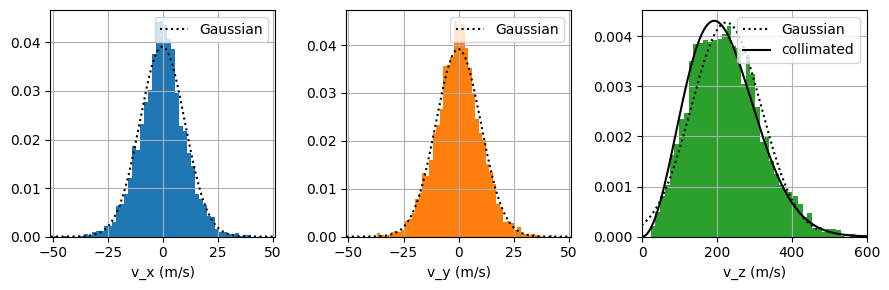

 > vx : mean = 0.35 m/s | std = 32.16 m/s
 > vy : mean = 2.27 m/s | std = 30.76 m/s
 > vz : mean = 236.72 m/s | std = 96.82 m/s


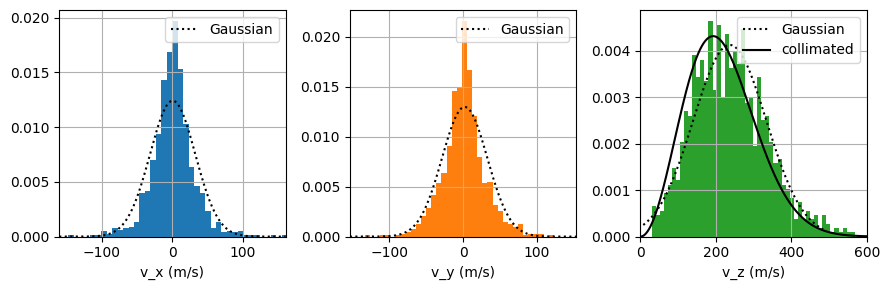

In [276]:
ax = plot_distrib(res, 2 * r, l, T, m)
ax = plot_distrib(res_spread, 2 * r, l, T, m)